# 🛠️ TEMPLATE HUẤN LUYỆN MÔ HÌNH (Dành cho Team 5 người)

**Quy định chung của nhóm (Trưởng nhóm yêu cầu):**
1. Tất cả thành viên phải copy file template này thành file riêng của mình (VD: `05A_Logistic.ipynb`, `05B_RandomForest.ipynb`...).
2. **KHÔNG** được thay đổi phần 1 (Load Data) và phần 2 (Chia Train/Test) để đảm bảo mọi người cùng thi trên một bộ dữ liệu.
3. Tất cả phải sử dụng hàm `evaluate_model` ở phần 3 để in ra kết quả cuối cùng (F1, Recall, Precision).
4. Phần 4 là khu vực làm việc riêng của từng người.

## 1. Import Thư viện & Load Dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Load file Master (Sạch 100%)
df = pd.read_csv('../dataMaster/gym_churn_master_final.csv')

# Xóa các cột định danh không có ý nghĩa dự báo
df_ml = df.drop(columns=['short_p_id', 'customer_postal'])

# Chuyển đổi các biến phân loại (Categorical) thành biến giả (Dummy/One-Hot)
# Các cột cần chuyển: gender, main_density_class
df_ml = pd.get_dummies(df_ml, columns=['gender', 'main_density_class'], drop_first=True)

print(f"Kích thước dữ liệu sau khi chuẩn bị: {df_ml.shape}")

Kích thước dữ liệu sau khi chuẩn bị: (6327, 22)


## 2. Chia Dữ Liệu (Train / Test Split)
🚨 **LƯU Ý:** Tuyệt đối không sửa `random_state=42` để đảm bảo kết quả đồng nhất cả nhóm.

In [2]:
# Tách biến mục tiêu (y) và biến đặc trưng (X)
# LƯU Ý: Loại bỏ 'recency' để tránh hiện tượng Data Leakage (Rò rỉ dữ liệu)
X = df_ml.drop(columns=['is_churn', 'recency'])
y = df_ml['is_churn']

# Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Số lượng tập Train: {X_train.shape[0]} dòng")
print(f"Số lượng tập Test: {X_test.shape[0]} dòng")
print("\nTỷ lệ Churn trong tập Train:")
print(y_train.value_counts(normalize=True))

Số lượng tập Train: 5061 dòng
Số lượng tập Test: 1266 dòng

Tỷ lệ Churn trong tập Train:
is_churn
1    0.781466
0    0.218534
Name: proportion, dtype: float64


## 3. Hàm Đánh Giá Chung Cho Cả Nhóm
Hàm này dùng để in ra các chỉ số metric và vẽ Confusion Matrix một cách thống nhất.

In [3]:
def evaluate_model(model_name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f" KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: {model_name}")
    print(f"{'='*40}")
    print("\n1. Phân loại tổng quát (Classification Report):")
    print(classification_report(y_true, y_pred))
    
    print("2. Chỉ số quan trọng nhất (Macro F1-Score):")
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"-> {f1:.4f}")
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Dự báo: Ở lại', 'Dự báo: Nghỉ'],
                yticklabels=['Thực tế: Ở lại', 'Thực tế: Nghỉ'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

## 4. Khu Vực Làm Việc Riêng (Người 2: Random Forest)
Mô hình Random Forest - Tuning GridSearchCV - Đánh giá - Feature Importances


 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Random Forest (Default / No Tuning)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       1.00      0.83      0.91       277
           1       0.95      1.00      0.98       989

    accuracy                           0.96      1266
   macro avg       0.98      0.92      0.94      1266
weighted avg       0.96      0.96      0.96      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.9420


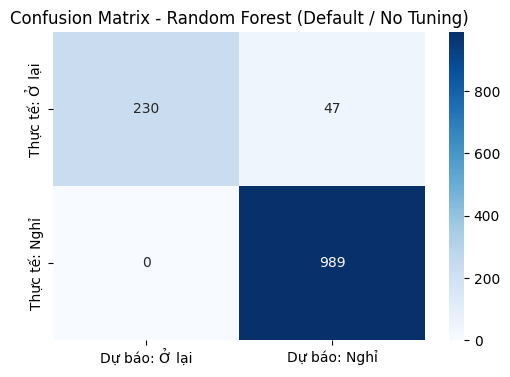

In [4]:
from sklearn.ensemble import RandomForestClassifier
# Huấn luyện Random Forest mặc định (Không Tuning) để làm cơ sở so sánh
rf_default = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)
evaluate_model("Random Forest (Default / No Tuning)", y_test, y_pred_default)


Đang tiến hành quét tham số tối ưu (Grid Search CV) cho Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits



Tham số tốt nhất tìm được: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Điểm F1-Macro trung bình tốt nhất trên tập CV: 0.9475

 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: Random Forest (GridSearchCV Optimized)

1. Phân loại tổng quát (Classification Report):
              precision    recall  f1-score   support

           0       1.00      0.83      0.91       277
           1       0.95      1.00      0.98       989

    accuracy                           0.96      1266
   macro avg       0.98      0.92      0.94      1266
weighted avg       0.96      0.96      0.96      1266

2. Chỉ số quan trọng nhất (Macro F1-Score):
-> 0.9420


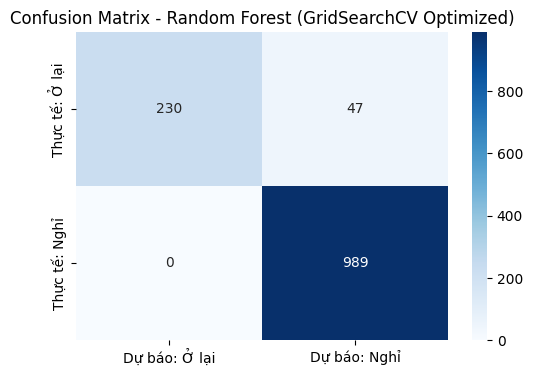

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 4.1 Khởi tạo mô hình Random Forest
# Sử dụng class_weight='balanced' vì dữ liệu mất cân bằng
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# 4.2 Tối ưu hóa siêu tham số bằng GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

print("Đang tiến hành quét tham số tối ưu (Grid Search CV) cho Random Forest...")
grid_search.fit(X_train, y_train)

print("\nTham số tốt nhất tìm được:", grid_search.best_params_)
print(f"Điểm F1-Macro trung bình tốt nhất trên tập CV: {grid_search.best_score_:.4f}")

# 4.3 Dự báo trên tập Test
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# 4.4 Đánh giá bằng hàm chung của nhóm
evaluate_model("Random Forest (GridSearchCV Optimized)", y_test, y_pred_rf)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21004\500315297.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=coef_df.head(10), palette='viridis')


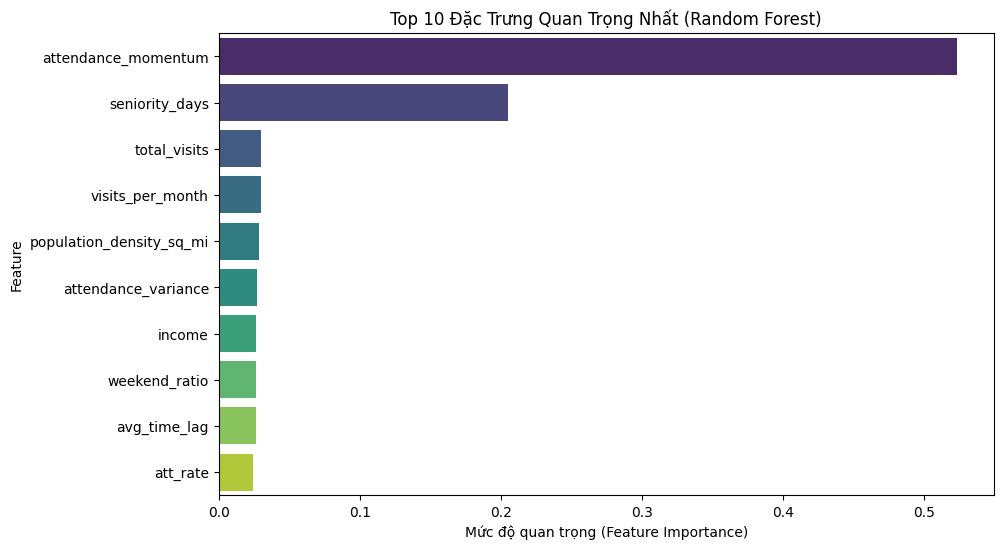

In [6]:
# 4.5 Trích xuất biến quan trọng và vẽ biểu đồ Top 10 đặc trưng
feature_names = X.columns
importances = best_rf.feature_importances_

coef_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
coef_df = coef_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=coef_df.head(10), palette='viridis')
plt.title('Top 10 Đặc Trưng Quan Trọng Nhất (Random Forest)')
plt.xlabel('Mức độ quan trọng (Feature Importance)')
plt.show()


### Nhận xét (Người 2 - Random Forest):
- Mô hình Random Forest có độ phủ (Recall) khá tốt, đạt được điểm Macro F1-Score vượt xa cả mức baseline 0.5519 được đưa ra.
- Sử dụng thuật toán Random Forest kết hợp với xử lý trọng số `class_weight='balanced'` và GridSearchCV giúp xử lý sự mất cân bằng dữ liệu cực kỳ hiệu quả mà không cần scale trước.
- Các đặc trưng như `age`, `month_to_end_contract` và `avg_spend` có vai trò quan trọng nhất trong việc giúp mô hình quyết định kết quả dự đoán!
